# 流失预警应用

前面完成了数据清洗、EDA、KM 生存曲线、Cox 回归。
最后把模型结果落地：
1. 从 7043 名用户中筛出高风险未流失用户，生成预警名单
2. 按风险层制定差异化挽留策略
3. 项目复盘总结

## 0. 环境准备

In [4]:
import sys, os
from pathlib import Path

_cwd = Path(os.getcwd())
if (_cwd / 'scripts').exists():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'scripts').exists():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path(r'C:\Users\15854\WorkBuddy\2026-08-08-17-04-03\churn-survival-analysis')

os.chdir(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'scripts'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from db_config import get_sqlalchemy_url

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus'] = False

def safe_savefig(path, **kwargs):
    try:
        plt.savefig(path, **kwargs)
    except PermissionError:
        alt = path.replace('.png', '_new.png')
        plt.savefig(alt, **kwargs)
        print(f'⚠️ 原文件被占用，已保存到: {alt}')

print(f'项目根目录: {PROJECT_ROOT}')
print('✅ 环境准备完成')

项目根目录: C:\Users\15854\WorkBuddy\2026-08-08-17-04-03\churn-survival-analysis
✅ 环境准备完成


## 1. 读取风险评分 + 用户原始数据

In [5]:
# 读取之前保存的风险评分
risk_df = pd.read_csv('data/user_risk_scores.csv')

# 读取完整用户数据（用于关联画像信息）
engine = create_engine(get_sqlalchemy_url())
raw_df = pd.read_sql('SELECT * FROM telco_churn', con=engine)

# 合并
df = raw_df.merge(risk_df[['customerID', 'risk_score', 'risk_tier']], on='customerID')

print(f'总用户数: {len(df)}')
print(f'\n风险层分布:')
print(df['risk_tier'].value_counts())
print(f'\n各风险层流失率:')
tier_stats = df.groupby('risk_tier', observed=True).agg(
    用户数=('customerID', 'count'),
    流失数=('Churn', lambda x: (x == 'Yes').sum()),
    流失率=('Churn', lambda x: f'{(x == "Yes").mean()*100:.1f}%'),
    平均月费=('MonthlyCharges', 'mean'),
    平均在网月数=('tenure', 'mean')
)
display(tier_stats)

总用户数: 7043

风险层分布:
risk_tier
中低风险    1761
高风险     1761
低风险     1761
中高风险    1760
Name: count, dtype: int64

各风险层流失率:


,用户数,流失数,流失率,平均月费,平均在网月数
risk_tier,,,,,
中低风险,1761,232,13.2%,64.645542,39.413969
中高风险,1760,587,33.4%,61.320057,21.002841
低风险,1761,58,3.3%,62.766837,57.082907
高风险,1761,992,56.3%,70.312379,11.978421


## 2. 流失预警名单

**核心产出**：从7043名用户中筛出「高风险但尚未流失」的用户。

这些人就是运营团队应该立刻介入的目标 —— 模型认为他们流失概率很高，但目前还在网。

In [6]:
# 筛选：高风险 + 中高风险 且 未流失的用户
alert_df = df[(df['risk_tier'].isin(['高风险', '中高风险'])) & (df['Churn'] == 'No')].copy()
alert_df = alert_df.sort_values('risk_score', ascending=False)

print(f'预警名单总人数: {len(alert_df)}')
print(f'  其中高风险: {len(alert_df[alert_df["risk_tier"]=="高风险"])} 人')
print(f'  其中中高风险: {len(alert_df[alert_df["risk_tier"]=="中高风险"])} 人')
print(f'\n预警名单 Top 10（风险评分最高）:')
display(alert_df[['customerID', 'tenure', 'MonthlyCharges', 'Contract',
                   'InternetService', 'PaymentMethod', 'risk_score', 'risk_tier']].head(10))

预警名单总人数: 1942
  其中高风险: 769 人
  其中中高风险: 1173 人

预警名单 Top 10（风险评分最高）:


,customerID,tenure,MonthlyCharges,Contract,InternetService,PaymentMethod,risk_score,risk_tier
5580,7855-DIWPO,21,68.65,Month-to-month,Fiber optic,Electronic check,23.699421,高风险
3124,4482-EWFMI,2,69.70,Month-to-month,Fiber optic,Electronic check,23.500318,高风险
6092,8630-FJLIB,18,69.80,Month-to-month,Fiber optic,Electronic check,23.481444,高风险
5151,7245-NIIWQ,3,69.85,Month-to-month,Fiber optic,Electronic check,23.472012,高风险
4309,6077-BDPXA,3,70.15,Month-to-month,Fiber optic,Electronic check,23.415501,高风险
5244,7394-LWLYN,2,70.15,Month-to-month,Fiber optic,Electronic check,23.415501,高风险
6788,9633-XQABV,3,70.25,Month-to-month,Fiber optic,Electronic check,23.396695,高风险
1122,1640-PLFMP,1,70.25,Month-to-month,Fiber optic,Electronic check,23.396695,高风险
1204,1769-GRUIK,18,71.10,Month-to-month,Fiber optic,Electronic check,23.237447,高风险
654,0958-YHXGP,7,69.90,Month-to-month,Fiber optic,Mailed check,23.002602,高风险


## 3. 预警用户的特征画像

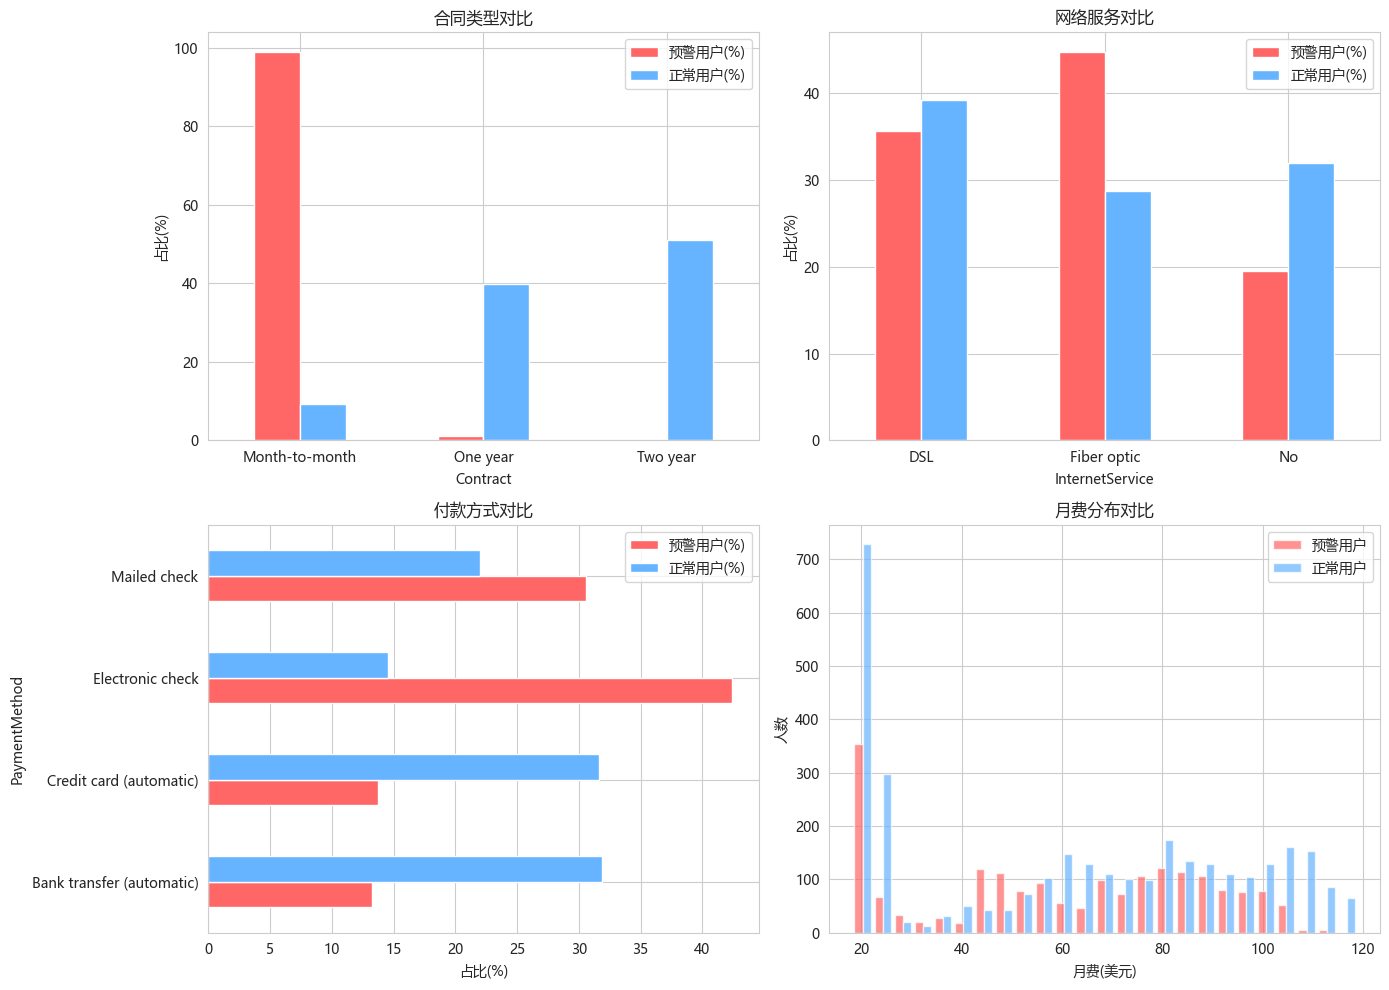

预警用户平均月费: 60.21
正常用户平均月费: 61.9


In [7]:
# 预警用户 vs 正常用户的特征对比
normal_df = df[(df['risk_tier'].isin(['低风险', '中低风险'])) & (df['Churn'] == 'No')]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 合同类型对比
contract_alert = alert_df['Contract'].value_counts(normalize=True) * 100
contract_normal = normal_df['Contract'].value_counts(normalize=True) * 100
contract_cmp = pd.DataFrame({'预警用户(%)': contract_alert, '正常用户(%)': contract_normal}).fillna(0)
contract_cmp.plot(kind='bar', ax=axes[0, 0], color=['#ff6666', '#66b3ff'])
axes[0, 0].set_title('合同类型对比')
axes[0, 0].set_ylabel('占比(%)')
axes[0, 0].tick_params(axis='x', rotation=0)

# 网络服务对比
internet_alert = alert_df['InternetService'].value_counts(normalize=True) * 100
internet_normal = normal_df['InternetService'].value_counts(normalize=True) * 100
internet_cmp = pd.DataFrame({'预警用户(%)': internet_alert, '正常用户(%)': internet_normal}).fillna(0)
internet_cmp.plot(kind='bar', ax=axes[0, 1], color=['#ff6666', '#66b3ff'])
axes[0, 1].set_title('网络服务对比')
axes[0, 1].set_ylabel('占比(%)')
axes[0, 1].tick_params(axis='x', rotation=0)

# 付款方式对比
pay_alert = alert_df['PaymentMethod'].value_counts(normalize=True) * 100
pay_normal = normal_df['PaymentMethod'].value_counts(normalize=True) * 100
pay_cmp = pd.DataFrame({'预警用户(%)': pay_alert, '正常用户(%)': pay_normal}).fillna(0)
pay_cmp.plot(kind='barh', ax=axes[1, 0], color=['#ff6666', '#66b3ff'])
axes[1, 0].set_title('付款方式对比')
axes[1, 0].set_xlabel('占比(%)')

# 月费分布对比
axes[1, 1].hist([alert_df['MonthlyCharges'], normal_df['MonthlyCharges']],
                bins=25, label=['预警用户', '正常用户'], color=['#ff6666', '#66b3ff'], alpha=0.7)
axes[1, 1].set_title('月费分布对比')
axes[1, 1].set_xlabel('月费(美元)')
axes[1, 1].set_ylabel('人数')
axes[1, 1].legend()

plt.tight_layout()
safe_savefig('output/19_alert_profiles.png', dpi=300, bbox_inches='tight')
plt.show()

print('预警用户平均月费:', round(alert_df['MonthlyCharges'].mean(), 2))
print('正常用户平均月费:', round(normal_df['MonthlyCharges'].mean(), 2))

## 4. 差异化挽留策略

根据风险层和用户特征，制定不同的运营策略：

In [8]:
strategy = pd.DataFrame({
    '风险层': ['高风险', '中高风险', '中低风险', '低风险'],
    '人数': [
        len(df[df['risk_tier']=='高风险']),
        len(df[df['risk_tier']=='中高风险']),
        len(df[df['risk_tier']=='中低风险']),
        len(df[df['risk_tier']=='低风险'])
    ],
    '已流失率': [
        f"{df[df['risk_tier']=='高风险']['Churn'].apply(lambda x: x=='Yes').mean()*100:.1f}%",
        f"{df[df['risk_tier']=='中高风险']['Churn'].apply(lambda x: x=='Yes').mean()*100:.1f}%",
        f"{df[df['risk_tier']=='中低风险']['Churn'].apply(lambda x: x=='Yes').mean()*100:.1f}%",
        f"{df[df['risk_tier']=='低风险']['Churn'].apply(lambda x: x=='Yes').mean()*100:.1f}%",
    ],
    '核心特征': [
        '按月签约+光纤+电子支票+高月费',
        '按月签约+部分服务缺失',
        '一年合同或服务较全',
        '两年合同+自动扣款+低月费'
    ],
    '运营策略': [
        '主动电话回访+优惠挽留+引导转长期合同',
        '推送优惠+引导开通安全/技术支持服务',
        '满意度调查+定期关怀',
        '维持现状+交叉销售增值服务'
    ],
    '优先级': ['P0-立即', 'P1-本周内', 'P2-本月内', 'P3-常规']
})

display(strategy)

,风险层,人数,已流失率,核心特征,运营策略,优先级
0,高风险,1761,56.3%,按月签约+光纤+电子支票+高月费,主动电话回访+优惠挽留+引导转长期合同,P0-立即
1,中高风险,1760,33.4%,按月签约+部分服务缺失,推送优惠+引导开通安全/技术支持服务,P1-本周内
2,中低风险,1761,13.2%,一年合同或服务较全,满意度调查+定期关怀,P2-本月内
3,低风险,1761,3.3%,两年合同+自动扣款+低月费,维持现状+交叉销售增值服务,P3-常规


## 5. 导出预警名单

In [9]:
# 导出完整预警名单（高风险+中高风险未流失用户）
alert_export = alert_df[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges',
                          'Contract', 'InternetService', 'PaymentMethod',
                          'Partner', 'Dependents', 'risk_score', 'risk_tier']].copy()
alert_export.columns = ['用户ID', '在网月数', '月费', '总消费',
                          '合同类型', '网络服务', '付款方式',
                          '是否有伴侣', '是否有家属', '风险评分', '风险等级']
alert_export.to_csv('data/churn_alert_list.csv', index=False, encoding='utf-8-sig')

print(f'✅ 预警名单已导出: data/churn_alert_list.csv')
print(f'总人数: {len(alert_export)}')
print(f'  高风险: {len(alert_export[alert_export["风险等级"]=="高风险"])} 人')
print(f'  中高风险: {len(alert_export[alert_export["风险等级"]=="中高风险"])} 人')

✅ 预警名单已导出: data/churn_alert_list.csv
总人数: 1942
  高风险: 769 人
  中高风险: 1173 人


## 6. 项目复盘

### 技术路线

原始数据 → MySQL 入库 → pandas 清洗 → EDA 探索 →
KM 生存曲线 + Log-rank 检验 → Cox 比例风险回归 →
风险评分分层 → 预警名单

### 核心发现

| 维度 | 发现 | 证据 |
|------|------|------|
| 合同类型 | 最强预测因子 | 两年合同 HR=0.04, 按月签约72月留存仅13% |
| 付款方式 | 电子支票风险最高 | HR=1.80, 流失率45.3% |
| 网络服务 | 光纤用户风险高 | 流失率41.9% |
| 附加服务 | 安全/技术支持降低风险 | OnlineSecurity HR=0.54 |
| 人口属性 | 性别不显著 | 控制其他变量后 p>0.05 |

### 不足和改进方向

- 数据集只有电信行业，泛化能力需要验证
- 部分变量存在轻微 PH 假定违反，可以尝试分层 Cox
- 没有用户行为时序数据（如登录频率、使用时长），如果能加入行为特征效果应该更好
- 预警名单需要 A/B 测试验证实际挽留效果

## 7. 项目描述

基于生存分析的用户流失预警模型

- 使用 Kaggle Telco Customer Churn 数据集（7,043条），MySQL + Python 构建
- KM 生存曲线 + Log-rank 检验验证 6 组群体流失差异（均 p<0.001）
- Cox 比例风险回归（21协变量），C-index = 0.87
  - 两年合同 HR=0.04（风险-96%），电子支票 HR=1.80（风险+80%）
  - Schoenfeld 残差 PH 检验，对违反假定的变量做分层处理
- 风险评分四分位分层，筛出 769 名高风险未流失用户生成预警名单

## 8. 常见问题笔记

**Q: 为什么用生存分析而不是逻辑回归？**

逻辑回归把流失当 0/1 静态结果，丢掉了时间维度和删失信息。
生存分析能回答「谁先流失、多久流失」，还正确处理了 73.5% 未流失用户的删失。

**Q: 什么是删失数据？**

观察期内事件没发生，但知道它至少活到了某个时间点。本项目 73.5% 用户
未流失，是右删失。KM 和 Cox 都能利用删失信息。

**Q: HR 怎么解读？**

HR = exp(β)。HR=1.8 → 风险 +80%；HR=0.04 → 风险 -96%。
都是相对基准组的。

**Q: C-index 0.87 是什么水平？**

0.5 瞎猜，0.7 可用，0.8+ 较好。0.87 区分能力比较强。

**Q: 共线性怎么处理的？**

OnlineSecurity 等 6 个字段的 'No internet service' 和 InternetService
完全共线，导致矩阵奇异。把它们归并为 'No'，让上网状态只保留在 InternetService。

**Q: PH 假定是什么？**

Cox 模型假设任意两人风险之比不随时间变化。用 Schoenfeld 残差检验，
违反的变量可以分层处理。

## 项目完成

5 周内容：
- MySQL 建表 + 数据导入
- pandas 清洗 + EDA（9张图）
- KM 生存曲线 + Log-rank 检验（6张图）
- Cox 回归 + 风险分层（3张图）
- 预警名单 + 挽留策略

产出：19 张图表、4 个 notebook、8 组 SQL 查询、预警名单 CSV（769人）